In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    # Install PyTorch Geometric
    !pip install -q torch-geometric

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step3 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP3_OUTPUT = f"{DRIVE_BASE}/extension_data/realized_task_graphs.pkl"
    LOCAL_STEP3_OUTPUT = "extension_data/realized_task_graphs.pkl"

    if os.path.exists(DRIVE_STEP3_OUTPUT) and not os.path.exists(LOCAL_STEP3_OUTPUT):
        print("Copying step3 output from Drive...")
        !cp "{DRIVE_STEP3_OUTPUT}" "{LOCAL_STEP3_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP3_OUTPUT):
        print("Step3 output already exists locally.")
    else:
        print("WARNING: Step3 output not found. Run extension_step3 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 947, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 947 (delta 115), reused 105 (delta 95), pack-reused 786 (from 2)
Receiving objects: 100% (947/947), 97.49 MiB | 33.29 MiB/s, done.
Resolving deltas: 100% (505/505), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 7.78 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, balanced_accuracy_score)
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Import PyTorch Geometric
try:
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool, global_max_pool
    from torch_geometric.loader import DataLoader as PyGDataLoader
    PYG_AVAILABLE = True
    print("PyTorch Geometric loaded successfully")
except ImportError:
    PYG_AVAILABLE = False
    print("PyTorch Geometric not available. Using simple baseline only.")

PyTorch Geometric loaded successfully


## 1. Load Realized Task Graphs

In [4]:
# Load the realized task graphs produced by Substep 3.
#
# Substep 3 writes one file per boundary source, and both are loaded here so that every
# model can be scored on both in a single pass:
#
# 'gt'           - annotated step boundaries. An oracle: the annotation lists only the
#                  steps that were performed.
# 'actionformer' - pre-trained ActionFormer boundaries, fewer recordings, and the step
#                  count comes from a detector rather than from the annotation.
#
# PRIMARY_SOURCE is the one the ablations further down analyse in detail.

_GRAPH_FILES = {'gt': 'realized_task_graphs.pkl',
                'actionformer': 'realized_task_graphs_actionformer.pkl',
                'actionformer_ours': 'realized_task_graphs_actionformer_ours.pkl'}


def _resolve(filename):
    """Prefer the Drive copy in Colab, fall back to the local extension_data folder."""
    if IN_COLAB:
        drive = "/content/drive/MyDrive/AML_Project/extension_data/" + filename
        if os.path.exists(drive):
            return drive
    local = os.path.join("extension_data", filename)
    return local if os.path.exists(local) else None


GRAPHS_BY_SOURCE, SPLITS_BY_SOURCE = {}, {}
config = None
for _source, _filename in _GRAPH_FILES.items():
    _path = _resolve(_filename)
    if _path is None:
        print(f"  {_source:<14} not found ({_filename}) - skipped")
        continue
    with open(_path, 'rb') as f:
        _loaded = pickle.load(f)
    GRAPHS_BY_SOURCE[_source] = _loaded['realized_graphs']
    SPLITS_BY_SOURCE[_source] = _loaded['splits']
    config = _loaded['config']
    print(f"  {_source:<14} {len(_loaded['realized_graphs']):>3} graphs   "
          f"structure: {config.get('task_graph_source', 'unknown')}   {_path}")

assert GRAPHS_BY_SOURCE, ("No realized task graphs found. "
                          "Run extension_step3_task_graph_matching.ipynb first.")

SOURCES = list(GRAPHS_BY_SOURCE)
PRIMARY_SOURCE = 'gt' if 'gt' in GRAPHS_BY_SOURCE else SOURCES[0]
realized_graphs = GRAPHS_BY_SOURCE[PRIMARY_SOURCE]
splits = SPLITS_BY_SOURCE[PRIMARY_SOURCE]
print(f"\nSources: {SOURCES}   primary: {PRIMARY_SOURCE}")
print(f"Feature dimension: {config['feature_dim']}")


  gt             383 graphs   structure: captaincook4d_dag   /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs.pkl
  actionformer   119 graphs   structure: captaincook4d_dag   /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs_actionformer.pkl
  actionformer_ours 383 graphs   structure: captaincook4d_dag   /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs_actionformer_ours.pkl

Sources: ['gt', 'actionformer', 'actionformer_ours']   primary: gt
Feature dimension: 256


In [5]:
FEATURE_DIM = config['feature_dim']

# Substep 3 stores the text and visual node features separately so the projection can
# be learned here. Fail loudly rather than silently falling back to the old format.
_sample = next(iter(realized_graphs.values()))
_required = ['node_text_features', 'node_visual_features', 'node_features', 'node_matched']
_missing = [k for k in _required if k not in _sample]
assert not _missing, (
    f"realized_task_graphs.pkl is missing {_missing}. It was produced by an older "
    f"Substep 3. Re-run extension_step3_task_graph_matching.ipynb to regenerate it."
)

# Node input to the model is [visual | text | matched_flag]; the combiner inside each
# model maps that back down to FEATURE_DIM.
NODE_INPUT_DIM = 2 * FEATURE_DIM + 1
print(f"Feature dim: {FEATURE_DIM}, raw node input dim: {NODE_INPUT_DIM}")

# Group by recipe type, per source
GROUPS_BY_SOURCE = {}
print(f"{'source':<14}{'recipes':>9}{'graphs':>8}{'nodes/graph':>13}"
      f"{'edges/graph':>13}{'incorrect':>11}")
print("-" * 68)
for source, graphs in GRAPHS_BY_SOURCE.items():
    groups = defaultdict(list)
    for recording_id, graph in graphs.items():
        groups[graph['recipe_id']].append(recording_id)
    GROUPS_BY_SOURCE[source] = groups

    n_nodes = [g['num_nodes'] for g in graphs.values()]
    n_edges = [g['edge_index'].shape[1] for g in graphs.values()]
    lab = [g['recipe_label'] for g in graphs.values()]
    print(f"{source:<14}{len(groups):>9}{len(graphs):>8}{np.mean(n_nodes):>13.1f}"
          f"{np.mean(n_edges):>13.1f}{np.mean(lab):>10.1%}")

recipe_groups = GROUPS_BY_SOURCE[PRIMARY_SOURCE]

Feature dim: 256, raw node input dim: 513
source          recipes  graphs  nodes/graph  edges/graph  incorrect
--------------------------------------------------------------------
gt                   24     383         14.6         15.3     57.2%
actionformer         24     119         14.7         15.4     61.3%
actionformer_ours       24     383         14.6         15.3     57.2%


## 2. Create PyG Data Objects

In [6]:
def create_pyg_data(realized_graph, recording_id, undirected=False):
    """
    Convert a realized graph to a PyTorch Geometric Data object.

    Node features are stacked as [visual | text | matched_flag] rather than pre-combined.
    `undirected=True` adds the reverse of every edge; the default keeps the task graph's
    own direction.
    The combiner module inside each model turns that into the node representation, which
    is what lets the spec's projection be *learned* from the classification loss instead
    of being a fixed average fixed at graph-construction time.
    """
    visual = np.asarray(realized_graph['node_visual_features'], dtype=np.float32)
    text = np.asarray(realized_graph['node_text_features'], dtype=np.float32)
    matched = np.asarray(realized_graph['node_matched'], dtype=np.float32).reshape(-1, 1)

    x = torch.FloatTensor(np.concatenate([visual, text, matched], axis=1))

    # CaptainCook4D task graphs are directed acyclic graphs and the direction encodes
    # procedural order: an edge a -> b means b depends on a. Symmetrising discards that,
    # so the directed graph is the primary formulation here and the undirected variant
    # is an explicit ablation further down.
    edge_index = realized_graph['edge_index']
    if undirected and edge_index.shape[1] > 0:
        edge_index = np.concatenate(
            [edge_index, np.array([edge_index[1], edge_index[0]])], axis=1)
    edge_index = torch.LongTensor(edge_index)

    y = torch.FloatTensor([realized_graph['recipe_label']])

    node_matched = torch.FloatTensor(realized_graph['node_matched'].astype(float))
    match_sims = torch.FloatTensor(realized_graph['match_similarities'])

    data = Data(
        x=x,
        edge_index=edge_index,
        y=y,
        node_matched=node_matched,
        match_sims=match_sims,
        recording_id=recording_id,
        recipe_id=realized_graph['recipe_id']
    )

    return data

if PYG_AVAILABLE:
    PYG_BY_SOURCE = {
        source: {rid: create_pyg_data(g, rid) for rid, g in graphs.items()}
        for source, graphs in GRAPHS_BY_SOURCE.items()
    }
    pyg_data = PYG_BY_SOURCE[PRIMARY_SOURCE]

    for source, data in PYG_BY_SOURCE.items():
        print(f"  {source:<14} {len(data):>3} PyG Data objects")

    sample = list(pyg_data.values())[0]
    print(f"\nSample graph:")
    print(f"  Nodes: {sample.x.shape}  (expected [n, {2 * FEATURE_DIM + 1}])")
    print(f"  Edges: {sample.edge_index.shape}")
    print(f"  Label: {sample.y.item()}")
    assert sample.x.shape[1] == NODE_INPUT_DIM

  gt             383 PyG Data objects
  actionformer   119 PyG Data objects
  actionformer_ours 383 PyG Data objects

Sample graph:
  Nodes: torch.Size([12, 513])  (expected [n, 513])
  Edges: torch.Size([2, 11])
  Label: 0.0


## 3. Define GNN Models

In [7]:
# ==============================================================================
# Node feature combiners
# ==============================================================================
# The spec for Substep 3 says: "update the features of the matched nodes with a
# learnable projection of the node features and the visual features."
#
# The projection lives here, not in Substep 3, because it can only be *learned* where
# there is a loss to train it. Substep 3 has no objective, so a projector instantiated
# there would apply a fixed random transform. Here it is the first module of the GNN and
# is trained end-to-end by the graph classification loss.
#
# Both combiners take the same raw node input [visual | text | matched_flag] so the two
# can be compared as a clean ablation on identical data and folds.

class LearnableProjection(nn.Module):
    """The spec's learnable projection, applied to the MATCHED nodes only.

    The spec says to "update the features of the matched nodes with a learnable
    projection of the node features and the visual features". An unmatched node has no
    visual evidence - its visual block is all zeros - so there is nothing to fuse, and
    it should keep the task graph's own text representation.

    An earlier version ran the projection over every node, including unmatched ones.
    That transformed nodes the spec says to leave alone, and it also made this module
    differ from FixedAverage in two ways at once (the fusion rule *and* whether
    unmatched nodes are touched), which muddied the ablation between them. Both now
    share the same gate, so the comparison isolates the fusion rule alone.
    """

    def __init__(self, feature_dim, hidden_dim=256):
        super().__init__()
        self.feature_dim = feature_dim
        self.proj = nn.Sequential(
            nn.Linear(feature_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim),
            nn.LayerNorm(feature_dim)
        )

    def forward(self, x):
        d = self.feature_dim
        visual, text, matched = x[:, :d], x[:, d:2 * d], x[:, 2 * d:2 * d + 1]
        fused = self.proj(torch.cat([text, visual], dim=-1))
        return matched * fused + (1.0 - matched) * text


class FixedAverage(nn.Module):
    """No-projection baseline, reproducing Substep 3's `node_features` exactly.

    Matched nodes get 0.5*visual + 0.5*text; unmatched nodes keep their text embedding
    (their visual slot is all zeros, so the matched flag is what selects between them).
    Has no parameters, so any gap against LearnableProjection is attributable to the
    projection itself rather than to extra capacity elsewhere.
    """

    def __init__(self, feature_dim):
        super().__init__()
        self.feature_dim = feature_dim

    def forward(self, x):
        d = self.feature_dim
        visual, text, matched = x[:, :d], x[:, d:2 * d], x[:, 2 * d:2 * d + 1]
        return matched * (0.5 * visual + 0.5 * text) + (1.0 - matched) * text


def make_combiner(kind, feature_dim, hidden_dim=256):
    if kind == 'projection':
        return LearnableProjection(feature_dim, hidden_dim)
    if kind == 'average':
        return FixedAverage(feature_dim)
    raise ValueError(f"unknown combiner: {kind!r} (expected 'projection' or 'average')")


if PYG_AVAILABLE:

    class GCNClassifier(nn.Module):
        """Graph Convolutional Network for graph classification."""

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

            self.convs = nn.ModuleList()
            self.bns = nn.ModuleList()

            self.convs.append(GCNConv(input_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

            for _ in range(num_layers - 1):
                self.convs.append(GCNConv(hidden_dim, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)

            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),  # *2 for mean+max pooling
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x, edge_index, batch):
            x = self.combiner(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.relu(x)
                x = self.dropout(x)

            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
            x = torch.cat([x_mean, x_max], dim=-1)

            return self.classifier(x)


    class GATClassifier(nn.Module):
        """Graph Attention Network for graph classification."""

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, heads=4, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

            self.convs = nn.ModuleList()
            self.bns = nn.ModuleList()

            self.convs.append(GATConv(input_dim, hidden_dim // heads, heads=heads, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

            for _ in range(num_layers - 1):
                self.convs.append(GATConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)

            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x, edge_index, batch):
            x = self.combiner(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.elu(x)
                x = self.dropout(x)

            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
            x = torch.cat([x_mean, x_max], dim=-1)

            return self.classifier(x)


    class GraphSAGEClassifier(nn.Module):
        """GraphSAGE for graph classification."""

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

            self.convs = nn.ModuleList()
            self.bns = nn.ModuleList()

            self.convs.append(SAGEConv(input_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

            for _ in range(num_layers - 1):
                self.convs.append(SAGEConv(hidden_dim, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)

            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x, edge_index, batch):
            x = self.combiner(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.relu(x)
                x = self.dropout(x)

            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
            x = torch.cat([x_mean, x_max], dim=-1)

            return self.classifier(x)

    print("GNN models defined (combiner: 'projection' | 'average')")

GNN models defined (combiner: 'projection' | 'average')


In [8]:
# Simple baseline without GNN (for comparison)
class SimplePoolingClassifier(nn.Module):
    """Ignores the graph structure: combine node features, pool, classify.

    This is the control for "does the task graph topology matter at all?" - it sees
    exactly the same node features as the GNNs but never propagates along an edge.
    """

    def __init__(self, input_dim, hidden_dim=128, dropout=0.3, combine='projection'):
        super().__init__()
        self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

        self.fc = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, batch):
        x = self.combiner(x)

        if PYG_AVAILABLE:
            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
        else:
            x_mean = x.mean(dim=0, keepdim=True)
            x_max = x.max(dim=0, keepdim=True)[0]

        x = torch.cat([x_mean, x_max], dim=-1)
        return self.fc(x)

print("Simple baseline defined")

Simple baseline defined


## 4. Training Functions

In [9]:
def train_epoch_gnn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y.view(-1, 1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

        preds = torch.sigmoid(out).detach().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(batch.y.cpu().numpy().flatten())

    return total_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)


def evaluate_gnn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.view(-1, 1))

            total_loss += loss.item() * batch.num_graphs

            preds = torch.sigmoid(out).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(batch.y.cpu().numpy().flatten())

    return total_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels, threshold=0.5, majority_class=None):
    """Metrics for a binary task with a ~61/39 class split.

    `preds` are probabilities, so AUC is computed on them directly rather than on
    thresholded predictions (thresholding first destroys the ranking AUC measures and
    pins it near the accuracy).

    Balanced accuracy is reported alongside F1 because F1 on the positive (majority)
    class rewards a model that predicts "incorrect" for everything - that degenerate
    predictor scores ~76% F1 here while being useless.
    """
    binary_preds = (preds >= threshold).astype(int)

    metrics = {
        'accuracy': accuracy_score(labels, binary_preds),
        'precision': precision_score(labels, binary_preds, zero_division=0),
        'recall': recall_score(labels, binary_preds, zero_division=0),
        'f1': f1_score(labels, binary_preds, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, binary_preds),
        'positive_rate': float(binary_preds.mean()),
    }

    try:
        metrics['auc'] = roc_auc_score(labels, preds)
    except ValueError:
        # Only one class present in this fold - AUC undefined.
        metrics['auc'] = float('nan')

    # Majority-class baseline. The class MUST come from the training labels; deriving it
    # from the test labels leaks the answer and flatters the baseline.
    if majority_class is not None:
        const = np.full_like(binary_preds, int(majority_class))
        metrics['majority_f1'] = f1_score(labels, const, zero_division=0)
        metrics['majority_accuracy'] = accuracy_score(labels, const)
        metrics['majority_balanced_accuracy'] = balanced_accuracy_score(labels, const)

    return metrics

## 5. Leave-One-Recipe-Out Evaluation

In [10]:
def leave_one_recipe_out_gnn(model_class, pyg_data, recipe_groups, input_dim,
                             num_epochs=50, lr=1e-3, batch_size=32,
                             pos_weight='auto', n_val_recipes=4, seed=0,
                             refit_on_full=False, verbose=True, **model_kwargs):
    """Nested leave-one-recipe-out cross-validation.

    Three properties make this protocol trustworthy:

    1. **A real validation split.** The recipes not under test are split into an inner
       training set and a held-out validation set of `n_val_recipes` recipes, and the
       epoch is chosen on validation loss. Selecting on training loss instead would
       always return the most overfit checkpoint, since it decreases monotonically.
       Splitting by recipe rather than by recording matters because recordings of the
       same recipe are near-duplicates of one another.

    2. **pos_weight derived from the data.** 57% of recordings are labelled incorrect,
       so a fixed pos_weight above 1.0 up-weights the majority class and pushes the
       model toward the degenerate all-positive predictor. 'auto' uses n_neg/n_pos
       computed on the training fold only.

    3. **Controlled randomness, not determinism.** Each fold seeds torch, which fixes
       weight initialisation and data order so two configurations are compared under the
       same draw. It does NOT make a run reproducible: PyG's scatter reductions and CUDA
       attention kernels are non-deterministic, and re-running this notebook unchanged
       moved pooled AUC by up to 2 points on GAT while SimplePooling, which has no
       scatter over edges, moved by 0.1. Treat differences of a few AUC points between
       configurations as unresolved.

    `refit_on_full=True` switches to the textbook nested-CV variant: after the inner
    split has chosen an epoch, the model is retrained from scratch for that many epochs
    on all k-1 non-test recipes, so the validation recipes contribute to the final fit.
    Default is False, which reports the model actually selected on validation. Both are
    leak-free; the refit uses the limited data more efficiently, at the cost of a second
    training run per fold.

    Returns (per_fold_results, pooled_predictions) where pooled_predictions holds the
    concatenated test probabilities and labels across all folds.
    """
    recipe_ids = sorted(recipe_groups.keys())
    all_results = []
    pooled_probs, pooled_labels, pooled_majority = [], [], []

    if verbose:
        print(f"\nNested leave-one-recipe-out over {len(recipe_ids)} recipes "
              f"({n_val_recipes} held out for validation inside each fold)")

    for fold_idx, test_recipe in enumerate(tqdm(recipe_ids, desc="Folds")):
        test_ids = [r for r in recipe_groups[test_recipe] if r in pyg_data]

        other_recipes = [r for r in recipe_ids if r != test_recipe]
        rng = np.random.default_rng(seed + fold_idx)
        rng.shuffle(other_recipes)

        val_recipes = other_recipes[:n_val_recipes]
        train_recipes = other_recipes[n_val_recipes:]

        train_ids = [r for rec in train_recipes for r in recipe_groups[rec] if r in pyg_data]
        val_ids = [r for rec in val_recipes for r in recipe_groups[rec] if r in pyg_data]

        if len(test_ids) < 2 or len(train_ids) < 10 or len(val_ids) < 2:
            continue

        train_data = [pyg_data[r] for r in train_ids]
        val_data = [pyg_data[r] for r in val_ids]
        test_data = [pyg_data[r] for r in test_ids]

        train_loader = PyGDataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader = PyGDataLoader(val_data, batch_size=batch_size, shuffle=False)
        test_loader = PyGDataLoader(test_data, batch_size=batch_size, shuffle=False)

        # --- training-fold statistics only -------------------------------------
        train_labels = np.array([float(pyg_data[r].y.item()) for r in train_ids])
        n_pos = float(train_labels.sum())
        n_neg = float(len(train_labels) - n_pos)
        majority_class = int(n_pos >= n_neg)

        if pos_weight == 'auto':
            fold_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0
        else:
            fold_pos_weight = float(pos_weight)

        torch.manual_seed(seed + fold_idx)
        model = model_class(input_dim, **model_kwargs).to(device)

        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([fold_pos_weight], device=device))
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        best_val_loss = float('inf')
        best_state = None
        best_epoch = -1

        for epoch in range(num_epochs):
            train_epoch_gnn(model, train_loader, optimizer, criterion, device)
            scheduler.step()

            val_loss, _, _ = evaluate_gnn(model, val_loader, criterion, device)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch

        if refit_on_full and best_epoch >= 0:
            # Standard nested-CV refit: the inner split existed only to choose the
            # epoch, so retrain from scratch for that many epochs on ALL k-1 non-test
            # recipes. Uses the fold's data more efficiently at the cost of a second
            # training run; pos_weight is recomputed on the enlarged training set and
            # the test recipe is still never touched.
            full_ids = train_ids + val_ids
            full_loader = PyGDataLoader([pyg_data[r] for r in full_ids],
                                        batch_size=batch_size, shuffle=True)
            full_labels = np.array([float(pyg_data[r].y.item()) for r in full_ids])
            f_pos = float(full_labels.sum())
            f_neg = float(len(full_labels) - f_pos)
            f_weight = (f_neg / f_pos) if (pos_weight == 'auto' and f_pos > 0) \
                else fold_pos_weight

            torch.manual_seed(seed + fold_idx)
            model = model_class(input_dim, **model_kwargs).to(device)
            criterion = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor([f_weight], device=device))
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max(best_epoch + 1, 1))
            for _ in range(best_epoch + 1):
                train_epoch_gnn(model, full_loader, optimizer, criterion, device)
                scheduler.step()
        elif best_state is not None:
            model.load_state_dict(best_state)

        # --- test fold, untouched until here -----------------------------------
        _, test_probs, test_labels = evaluate_gnn(model, test_loader, criterion, device)
        metrics = compute_metrics(test_probs, test_labels, majority_class=majority_class)

        pooled_probs.append(test_probs)
        pooled_labels.append(test_labels)
        pooled_majority.append(np.full_like(test_labels, majority_class))

        all_results.append({
            'fold': fold_idx,
            'test_recipe': test_recipe,
            'train_size': len(train_ids),
            'val_size': len(val_ids),
            'test_size': len(test_ids),
            'pos_weight': fold_pos_weight,
            'selected_epoch': best_epoch,
            **metrics
        })

    pooled = {
        'probs': np.concatenate(pooled_probs) if pooled_probs else np.array([]),
        'labels': np.concatenate(pooled_labels) if pooled_labels else np.array([]),
        'majority': np.concatenate(pooled_majority) if pooled_majority else np.array([]),
    }

    return all_results, pooled


def summarize_results(results, pooled, model_name, num_epochs=None):
    """Report POOLED metrics as the headline.

    Folds hold 3-6 recordings, so a single fold's F1 can take only a handful of discrete
    values, and averaging across folds additionally weights every recipe equally
    regardless of size. Pooling the predictions across folds and scoring once avoids
    both effects; the per-fold spread is retained as a dispersion diagnostic.
    """
    metric_names = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'auc']

    probs, labels, majority = pooled['probs'], pooled['labels'], pooled['majority']
    binary = (probs >= 0.5).astype(int)

    pooled_metrics = {
        'accuracy': accuracy_score(labels, binary),
        'precision': precision_score(labels, binary, zero_division=0),
        'recall': recall_score(labels, binary, zero_division=0),
        'f1': f1_score(labels, binary, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, binary),
        'auc': roc_auc_score(labels, probs),
    }
    majority_metrics = {
        'accuracy': accuracy_score(labels, majority),
        'f1': f1_score(labels, majority, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, majority),
        'auc': 0.5,
    }

    print(f"\n{'='*66}")
    print(f"{model_name}  -  pooled over {len(results)} folds, {len(labels)} recordings")
    print(f"{'='*66}")
    print(f"{'metric':<20}{'model':>12}{'majority':>12}")
    for m in metric_names:
        maj = majority_metrics.get(m)
        maj_str = f"{maj*100:>11.2f}%" if maj is not None else f"{'-':>12}"
        print(f"{m:<20}{pooled_metrics[m]*100:>11.2f}%{maj_str}")

    print(f"\nPer-fold spread (diagnostic, not the headline):")
    for m in metric_names:
        vals = [r[m] for r in results if not np.isnan(r[m])]
        print(f"  {m:<18}{np.mean(vals)*100:>7.2f}% +/- {np.std(vals)*100:.2f}%")

    sel = [r['selected_epoch'] for r in results]
    tail = f" of {num_epochs}" if num_epochs else ""
    print(f"\nSelected epoch: mean {np.mean(sel):.1f}{tail}, "
          f"median {np.median(sel):.0f}, max {np.max(sel)}")
    if num_epochs and np.mean(sel) < 0.1 * num_epochs:
        # Converging early is not the same as failing. Decide from the pooled AUC
        # whether the model learned something before it started overfitting.
        if pooled_metrics['auc'] > 0.60:
            verdict = ("it still beats the baseline comfortably, so this is fast "
                       "convergence followed by overfitting, not failure to learn")
        else:
            verdict = ("and it does not beat the baseline: the model is memorising "
                       "the training folds rather than learning from them")
        print(f"  -> validation loss bottoms out within the first few epochs; {verdict}.")
    print(f"Positive rate: {binary.mean():.2%} (true: {labels.mean():.2%})")
    print(f"{'='*66}")

    out = {m: {'pooled': pooled_metrics[m],
               'fold_mean': float(np.mean([r[m] for r in results if not np.isnan(r[m])])),
               'fold_std': float(np.std([r[m] for r in results if not np.isnan(r[m])]))}
           for m in metric_names}
    out['_majority'] = majority_metrics
    out['_selected_epoch_mean'] = float(np.mean(sel))
    return out

## 6. Train and Evaluate All Models

In [11]:
# ==============================================================================
# EXPERIMENT CONFIGURATION
# ==============================================================================

NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
POS_WEIGHT = 'auto'      # n_neg/n_pos on the training fold; was hardcoded 2.0
HIDDEN_DIM = 128
NUM_LAYERS = 3
N_VAL_RECIPES = 4        # inner validation split, by recipe
SEED = 0
COMBINE = 'projection'   # 'projection' (spec) or 'average' (no-projection baseline)

print("Configuration")
print(f"  epochs={NUM_EPOCHS}  lr={LEARNING_RATE}  batch={BATCH_SIZE}")
print(f"  hidden={HIDDEN_DIM}  layers={NUM_LAYERS}  combiner={COMBINE}")
print(f"  pos_weight={POS_WEIGHT}  val_recipes={N_VAL_RECIPES}  seed={SEED}")

all_model_results = {}
all_fold_results = {}

Configuration
  epochs=50  lr=0.001  batch=32
  hidden=128  layers=3  combiner=projection
  pos_weight=auto  val_recipes=4  seed=0


In [12]:
if PYG_AVAILABLE:
    for source in SOURCES:
        print("\n" + "=" * 66)
        print(f"Training Simple Pooling Baseline (no graph structure) - {source} boundaries")
        print("=" * 66)

        _folds, _pooled = leave_one_recipe_out_gnn(
            SimplePoolingClassifier,
            PYG_BY_SOURCE[source],
            GROUPS_BY_SOURCE[source],
            input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT,
            n_val_recipes=N_VAL_RECIPES,
            seed=SEED,
            hidden_dim=HIDDEN_DIM,
            combine=COMBINE
        )

        all_fold_results[(source, 'SimplePooling')] = _folds
        all_model_results[(source, 'SimplePooling')] = summarize_results(
            _folds, _pooled, f"Simple Pooling Baseline (no graph structure) - {source} boundaries", num_epochs=NUM_EPOCHS)



Training Simple Pooling Baseline (no graph structure) - gt boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [01:37<00:00,  4.06s/it]



Simple Pooling Baseline (no graph structure) - gt boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  75.98%      57.18%
precision                 89.44%           -
recall                    65.75%           -
f1                        75.79%      72.76%
balanced_accuracy         77.69%      50.00%
auc                       81.40%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            75.60% +/- 10.56%
  precision           91.66% +/- 12.54%
  recall              64.94% +/- 19.36%
  f1                  73.45% +/- 12.83%
  balanced_accuracy   77.03% +/- 9.51%
  auc                 82.27% +/- 9.02%

Selected epoch: mean 4.3 of 50, median 4, max 8
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 42.04% (true: 57.18%)

Training Simple Pooling Baseli

Folds: 100%|██████████| 24/24 [00:30<00:00,  1.27s/it]



Simple Pooling Baseline (no graph structure) - actionformer boundaries  -  pooled over 24 folds, 119 recordings
metric                     model    majority
accuracy                  66.39%      61.34%
precision                 75.38%           -
recall                    67.12%           -
f1                        71.01%      76.04%
balanced_accuracy         66.17%      50.00%
auc                       63.73%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            66.32% +/- 19.80%
  precision           69.58% +/- 31.03%
  recall              68.75% +/- 34.13%
  f1                  66.17% +/- 28.59%
  balanced_accuracy   64.93% +/- 19.39%
  auc                 66.32% +/- 26.16%

Selected epoch: mean 6.6 of 50, median 6, max 11
Positive rate: 54.62% (true: 61.34%)

Training Simple Pooling Baseline (no graph structure) - actionformer_ours boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [01:35<00:00,  3.99s/it]


Simple Pooling Baseline (no graph structure) - actionformer_ours boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  60.84%      57.18%
precision                 68.65%           -
recall                    57.99%           -
f1                        62.87%      72.76%
balanced_accuracy         61.31%      50.00%
auc                       63.99%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            60.52% +/- 15.03%
  precision           67.92% +/- 17.87%
  recall              57.15% +/- 27.27%
  f1                  58.57% +/- 21.03%
  balanced_accuracy   60.21% +/- 13.12%
  auc                 68.64% +/- 13.67%

Selected epoch: mean 3.9 of 50, median 4, max 6
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 48.30% (true: 57.18%)


In [13]:
if PYG_AVAILABLE:
    for source in SOURCES:
        print("\n" + "=" * 66)
        print(f"Training GCN - {source} boundaries")
        print("=" * 66)

        _folds, _pooled = leave_one_recipe_out_gnn(
            GCNClassifier,
            PYG_BY_SOURCE[source],
            GROUPS_BY_SOURCE[source],
            input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT,
            n_val_recipes=N_VAL_RECIPES,
            seed=SEED,
            hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            combine=COMBINE
        )

        all_fold_results[(source, 'GCN')] = _folds
        all_model_results[(source, 'GCN')] = summarize_results(
            _folds, _pooled, f"GCN - {source} boundaries", num_epochs=NUM_EPOCHS)



Training GCN - gt boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:31<00:00,  6.32s/it]



GCN - gt boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  69.19%      57.18%
precision                 77.60%           -
recall                    64.84%           -
f1                        70.65%      72.76%
balanced_accuracy         69.92%      50.00%
auc                       77.46%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            69.22% +/- 10.34%
  precision           79.66% +/- 18.71%
  recall              64.94% +/- 20.28%
  f1                  68.51% +/- 14.79%
  balanced_accuracy   70.98% +/- 11.43%
  auc                 80.09% +/- 9.29%

Selected epoch: mean 3.0 of 50, median 3, max 4
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 47.78% (true: 57.18%)

Training GCN - actionformer boundaries

Nested leave-one-recipe-out ov

Folds: 100%|██████████| 24/24 [00:50<00:00,  2.09s/it]



GCN - actionformer boundaries  -  pooled over 24 folds, 119 recordings
metric                     model    majority
accuracy                  67.23%      61.34%
precision                 79.31%           -
recall                    63.01%           -
f1                        70.23%      76.04%
balanced_accuracy         68.46%      50.00%
auc                       77.78%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            65.62% +/- 22.95%
  precision           75.14% +/- 32.67%
  recall              59.72% +/- 31.79%
  f1                  63.78% +/- 28.98%
  balanced_accuracy   62.85% +/- 25.20%
  auc                 71.99% +/- 26.46%

Selected epoch: mean 7.2 of 50, median 5, max 20
Positive rate: 48.74% (true: 61.34%)

Training GCN - actionformer_ours boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:26<00:00,  6.09s/it]


GCN - actionformer_ours boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  61.62%      57.18%
precision                 68.95%           -
recall                    59.82%           -
f1                        64.06%      72.76%
balanced_accuracy         61.92%      50.00%
auc                       66.46%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            61.35% +/- 12.07%
  precision           69.85% +/- 15.02%
  recall              60.18% +/- 25.83%
  f1                  60.81% +/- 16.67%
  balanced_accuracy   62.28% +/- 10.62%
  auc                 70.26% +/- 11.94%

Selected epoch: mean 2.4 of 50, median 2, max 5
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 49.61% (true: 57.18%)


In [14]:
if PYG_AVAILABLE:
    for source in SOURCES:
        print("\n" + "=" * 66)
        print(f"Training GAT - {source} boundaries")
        print("=" * 66)

        _folds, _pooled = leave_one_recipe_out_gnn(
            GATClassifier,
            PYG_BY_SOURCE[source],
            GROUPS_BY_SOURCE[source],
            input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT,
            n_val_recipes=N_VAL_RECIPES,
            seed=SEED,
            hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            combine=COMBINE
        )

        all_fold_results[(source, 'GAT')] = _folds
        all_model_results[(source, 'GAT')] = summarize_results(
            _folds, _pooled, f"GAT - {source} boundaries", num_epochs=NUM_EPOCHS)



Training GAT - gt boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [03:10<00:00,  7.94s/it]



GAT - gt boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  67.62%      57.18%
precision                 74.61%           -
recall                    65.75%           -
f1                        69.90%      72.76%
balanced_accuracy         67.94%      50.00%
auc                       74.41%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            67.80% +/- 12.82%
  precision           77.89% +/- 18.08%
  recall              65.97% +/- 20.47%
  f1                  68.04% +/- 15.56%
  balanced_accuracy   69.20% +/- 11.78%
  auc                 79.30% +/- 11.86%

Selected epoch: mean 5.1 of 50, median 5, max 10
Positive rate: 50.39% (true: 57.18%)

Training GAT - actionformer boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [01:02<00:00,  2.61s/it]



GAT - actionformer boundaries  -  pooled over 24 folds, 119 recordings
metric                     model    majority
accuracy                  60.50%      61.34%
precision                 76.00%           -
recall                    52.05%           -
f1                        61.79%      76.04%
balanced_accuracy         62.98%      50.00%
auc                       64.32%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            59.72% +/- 18.57%
  precision           70.62% +/- 36.20%
  recall              49.31% +/- 29.55%
  f1                  54.79% +/- 27.73%
  balanced_accuracy   58.33% +/- 22.08%
  auc                 63.54% +/- 30.67%

Selected epoch: mean 8.2 of 50, median 6, max 30
Positive rate: 42.02% (true: 61.34%)

Training GAT - actionformer_ours boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [03:11<00:00,  7.99s/it]


GAT - actionformer_ours boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  63.97%      57.18%
precision                 73.68%           -
recall                    57.53%           -
f1                        64.62%      72.76%
balanced_accuracy         65.05%      50.00%
auc                       65.63%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            64.07% +/- 11.85%
  precision           76.52% +/- 16.29%
  recall              59.33% +/- 26.00%
  f1                  61.94% +/- 17.72%
  balanced_accuracy   66.56% +/- 10.15%
  auc                 70.75% +/- 12.73%

Selected epoch: mean 3.9 of 50, median 4, max 7
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 44.65% (true: 57.18%)


In [15]:
if PYG_AVAILABLE:
    for source in SOURCES:
        print("\n" + "=" * 66)
        print(f"Training GraphSAGE - {source} boundaries")
        print("=" * 66)

        _folds, _pooled = leave_one_recipe_out_gnn(
            GraphSAGEClassifier,
            PYG_BY_SOURCE[source],
            GROUPS_BY_SOURCE[source],
            input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT,
            n_val_recipes=N_VAL_RECIPES,
            seed=SEED,
            hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            combine=COMBINE
        )

        all_fold_results[(source, 'GraphSAGE')] = _folds
        all_model_results[(source, 'GraphSAGE')] = summarize_results(
            _folds, _pooled, f"GraphSAGE - {source} boundaries", num_epochs=NUM_EPOCHS)



Training GraphSAGE - gt boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:22<00:00,  5.94s/it]



GraphSAGE - gt boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  73.63%      57.18%
precision                 85.12%           -
recall                    65.30%           -
f1                        73.90%      72.76%
balanced_accuracy         75.03%      50.00%
auc                       80.70%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            73.46% +/- 10.50%
  precision           88.27% +/- 13.13%
  recall              64.98% +/- 22.78%
  f1                  71.03% +/- 14.94%
  balanced_accuracy   74.67% +/- 9.47%
  auc                 84.72% +/- 9.52%

Selected epoch: mean 3.9 of 50, median 4, max 8
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 43.86% (true: 57.18%)

Training GraphSAGE - actionformer boundaries

Nested leave-one-re

Folds: 100%|██████████| 24/24 [00:47<00:00,  1.98s/it]



GraphSAGE - actionformer boundaries  -  pooled over 24 folds, 119 recordings
metric                     model    majority
accuracy                  64.71%      61.34%
precision                 77.19%           -
recall                    60.27%           -
f1                        67.69%      76.04%
balanced_accuracy         66.01%      50.00%
auc                       69.39%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            65.07% +/- 20.86%
  precision           64.93% +/- 37.63%
  recall              59.38% +/- 40.28%
  f1                  57.71% +/- 34.92%
  balanced_accuracy   63.37% +/- 19.02%
  auc                 61.11% +/- 35.04%

Selected epoch: mean 5.7 of 50, median 6, max 13
Positive rate: 47.90% (true: 61.34%)

Training GraphSAGE - actionformer_ours boundaries

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:21<00:00,  5.90s/it]


GraphSAGE - actionformer_ours boundaries  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  60.84%      57.18%
precision                 70.91%           -
recall                    53.42%           -
f1                        60.94%      72.76%
balanced_accuracy         62.08%      50.00%
auc                       66.54%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            61.03% +/- 14.76%
  precision           74.52% +/- 24.44%
  recall              52.86% +/- 29.95%
  f1                  55.50% +/- 24.81%
  balanced_accuracy   60.08% +/- 13.23%
  auc                 71.88% +/- 14.57%

Selected epoch: mean 2.3 of 50, median 2, max 6
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 43.08% (true: 57.18%)


## 7. Results Comparison

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

METRICS = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'auc']

rows = []
for source in SOURCES:
    for (src, model_name), res in all_model_results.items():
        if src != source:
            continue
        rows.append({'Boundaries': source, 'Model': model_name,
                     **{m: f"{res[m]['pooled'] * 100:.1f}%" for m in METRICS},
                     'sel.epoch': f"{res['_selected_epoch_mean']:.1f}"})

    # The majority baseline depends only on the label set, so it is one row per source.
    _same = [r for (s, _), r in all_model_results.items() if s == source]
    if _same:
        maj = _same[0]['_majority']
        rows.append({'Boundaries': source, 'Model': 'Majority baseline',
                     **{m: (f"{maj[m] * 100:.1f}%" if m in maj else '-') for m in METRICS},
                     'sel.epoch': '-'})

df = pd.DataFrame(rows)
print("\n" + "=" * 92)
print("GNN comparison - POOLED nested leave-one-recipe-out")
print("=" * 92)
print(df.to_string(index=False))

print("\nRead balanced_accuracy and auc, not f1. Positive rates differ between the two")
print("sources, so the f1 column is not comparable across boundary types:")
for source, graphs in GRAPHS_BY_SOURCE.items():
    _rate = np.mean([g['recipe_label'] for g in graphs.values()])
    _same = [r for (s, _), r in all_model_results.items() if s == source]
    _maj = _same[0]['_majority']['f1'] if _same else float('nan')
    print(f"  {source:<14} {len(graphs):>3} recordings, {_rate:.0%} incorrect, "
          f"majority f1 {_maj:.1%} at 50.0% balanced accuracy")



GNN comparison - POOLED nested leave-one-recipe-out
       Boundaries             Model accuracy precision recall    f1 balanced_accuracy   auc sel.epoch
               gt     SimplePooling    76.0%     89.4%  65.8% 75.8%             77.7% 81.4%       4.3
               gt               GCN    69.2%     77.6%  64.8% 70.6%             69.9% 77.5%       3.0
               gt               GAT    67.6%     74.6%  65.8% 69.9%             67.9% 74.4%       5.1
               gt         GraphSAGE    73.6%     85.1%  65.3% 73.9%             75.0% 80.7%       3.9
               gt Majority baseline    57.2%         -      - 72.8%             50.0% 50.0%         -
     actionformer     SimplePooling    66.4%     75.4%  67.1% 71.0%             66.2% 63.7%       6.6
     actionformer               GCN    67.2%     79.3%  63.0% 70.2%             68.5% 77.8%       7.2
     actionformer               GAT    60.5%     76.0%  52.1% 61.8%             63.0% 64.3%       8.2
     actionformer         Gra

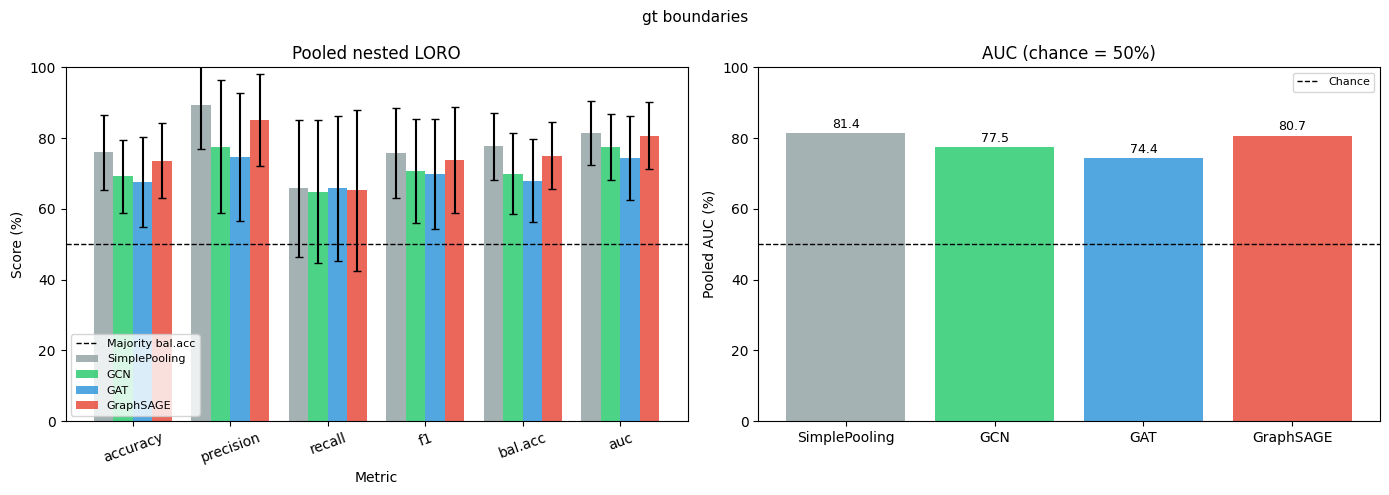

In [17]:
# Visualization - one chart per boundary source keeps the bars readable.
_plot_keys = [(s_, m_) for (s_, m_) in all_model_results if s_ == PRIMARY_SOURCE]
if _plot_keys:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{PRIMARY_SOURCE} boundaries", fontsize=11)

    model_names = _plot_keys
    colors = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c']

    x = np.arange(len(METRICS))
    width = 0.8 / max(len(model_names), 1)

    for i, name in enumerate(model_names):
        res = all_model_results[name]
        means = [res[m]['pooled'] * 100 for m in METRICS]
        # Error bars show the per-fold spread around the pooled value, which is a
        # dispersion diagnostic - the bar height itself is the pooled metric.
        stds = [res[m]['fold_std'] * 100 for m in METRICS]
        axes[0].bar(x + i * width, means, width, yerr=stds, label=name[1],
                    color=colors[i % len(colors)], alpha=0.85, capsize=3)

    maj = all_model_results[model_names[0]]['_majority']
    axes[0].axhline(maj['balanced_accuracy'] * 100, color='k', linestyle='--',
                    linewidth=1, label='Majority bal.acc')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Score (%)')
    axes[0].set_title('Pooled nested LORO')
    axes[0].set_xticks(x + width * (len(model_names) - 1) / 2)
    axes[0].set_xticklabels([m.replace('balanced_accuracy', 'bal.acc') for m in METRICS],
                            rotation=20)
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0, 100)

    # AUC is the metric least fooled by the class imbalance, so compare on it directly.
    auc_vals = [all_model_results[m]['auc']['pooled'] * 100 for m in model_names]
    bars = axes[1].bar([m[1] for m in model_names], auc_vals,
                       color=colors[:len(model_names)], alpha=0.85)
    axes[1].axhline(50, color='k', linestyle='--', linewidth=1, label='Chance')
    axes[1].set_ylabel('Pooled AUC (%)')
    axes[1].set_title('AUC (chance = 50%)')
    axes[1].set_ylim(0, 100)
    axes[1].legend(fontsize=8)

    for bar, v in zip(bars, auc_vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                     f'{v:.1f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('extension_data/gnn_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [18]:
# Save all results
import json

def convert_numpy(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    return obj

def _flatten(d):
    """Results are keyed by (source, model); JSON needs a string key."""
    return {f"{source}/{model}": v for (source, model), v in d.items()}


results_to_save = {
    'summary': _flatten(all_model_results),
    'folds': _flatten(all_fold_results),
    'config': {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'pos_weight': POS_WEIGHT,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'n_val_recipes': N_VAL_RECIPES,
        'seed': SEED,
        'combine': COMBINE,
        'feature_dim': FEATURE_DIM,
        'protocol': 'nested leave-one-recipe-out, epoch selected on validation loss',
        'sources': SOURCES,
        'task_graph_source': config.get('task_graph_source', 'unknown'),
    }
}

if 'ablation_results' in dir():
    results_to_save['projection_ablation'] = ablation_results

with open('extension_data/gnn_results.json', 'w') as f:
    json.dump(convert_numpy(results_to_save), f, indent=2)

print("Results saved to extension_data/gnn_results.json")

Results saved to extension_data/gnn_results.json


---
## 7b. Ablation: learnable projection vs fixed average

The spec asks for a **learnable projection** of the node features and the visual
features. The obvious cheaper alternative is the fixed `0.5*visual + 0.5*text` average.
This runs the best-performing architecture both ways on identical folds, identical
seeds and identical data, so the difference is attributable to the projection alone.

Reporting this as an ablation matters because the projection is not free: it adds
~198k parameters to a model trained on 383 graphs, and on a dataset this small extra
capacity is as likely to hurt as to help. The measured answer goes in the report either
way.

In [19]:
# Ablation: does the learnable projection actually beat the fixed average?
if PYG_AVAILABLE:
    ABLATION_MODEL = GraphSAGEClassifier
    ABLATION_NAME = 'GraphSAGE'

    ablation_results = {}
    for combine in ['average', 'projection']:
        print("\n" + "=" * 66)
        print(f"{ABLATION_NAME} with combiner = {combine!r}")
        print("=" * 66)

        _folds, _pooled = leave_one_recipe_out_gnn(
            ABLATION_MODEL,
            pyg_data,
            recipe_groups,
            input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT,
            n_val_recipes=N_VAL_RECIPES,
            seed=SEED,
            hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            combine=combine,
        )
        ablation_results[combine] = summarize_results(
            _folds, _pooled, f"{ABLATION_NAME} ({combine})", num_epochs=NUM_EPOCHS)

    print("\n" + "=" * 66)
    print("PROJECTION ABLATION")
    print("=" * 66)
    print(f"{'metric':<20}{'average':>12}{'projection':>13}{'delta':>10}")
    for m in ['f1', 'balanced_accuracy', 'auc']:
        a = ablation_results['average'][m]['pooled'] * 100
        p = ablation_results['projection'][m]['pooled'] * 100
        print(f"{m:<20}{a:>11.2f}%{p:>12.2f}%{p - a:>+9.2f}")
    print("\nA delta within a couple of points is noise at n=383 with 24 folds;")
    print("report it as such rather than as evidence the projection helps.")


GraphSAGE with combiner = 'average'

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:08<00:00,  5.35s/it]



GraphSAGE (average)  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  68.15%      57.18%
precision                 79.04%           -
recall                    60.27%           -
f1                        68.39%      72.76%
balanced_accuracy         69.47%      50.00%
auc                       74.91%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            67.52% +/- 13.39%
  precision           82.60% +/- 15.23%
  recall              58.29% +/- 27.01%
  f1                  62.98% +/- 20.24%
  balanced_accuracy   68.20% +/- 10.69%
  auc                 77.75% +/- 11.21%

Selected epoch: mean 5.5 of 50, median 6, max 9
Positive rate: 43.60% (true: 57.18%)

GraphSAGE with combiner = 'projection'

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:16<00:00,  5.69s/it]


GraphSAGE (projection)  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  75.98%      57.18%
precision                 88.96%           -
recall                    66.21%           -
f1                        75.92%      72.76%
balanced_accuracy         77.62%      50.00%
auc                       82.13%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            75.44% +/- 13.50%
  precision           90.72% +/- 10.65%
  recall              65.51% +/- 24.79%
  f1                  72.38% +/- 19.48%
  balanced_accuracy   76.36% +/- 12.47%
  auc                 85.61% +/- 8.99%

Selected epoch: mean 3.8 of 50, median 4, max 11
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 42.56% (true: 57.18%)

PROJECTION ABLATION
metric                   average   projection 

## Summary

**Substep 4: GNN classification of the realized task graph.**

1. Converted realized task graphs to PyTorch Geometric format, keeping visual and text
   node features separate as `[visual | text | matched_flag]`
2. Implemented the learnable projection as the first module of each model, trained
   end-to-end by the classification loss, with a fixed `0.5/0.5` average retained as a
   parameter-free control
3. Compared SimplePooling (no edges), GCN, GAT and GraphSAGE
4. Evaluated with nested leave-one-recipe-out cross-validation, selecting the epoch on a
   held-out validation split of four recipes
5. Ran a depth study under the same protocol

### Reading the results

- **Use balanced accuracy and AUC rather than F1.** 57% of recordings are labelled
  incorrect, so a model that predicts "incorrect" everywhere already scores a high F1.
  The majority baseline is printed in the same table for this reason.
- **Check `sel.epoch`.** Validation loss bottoming out within the first few epochs means
  the model converges almost immediately; whether that constitutes failure depends on
  whether it beats the baseline, which the summary reports alongside it.
- **Compare against SimplePooling.** It receives identical node features but no edges, so
  any claim that the task-graph structure contributes has to appear as a gap over it.
- **Treat small differences as noise.** Repeated runs of an identical configuration differ
  by roughly 0.4-0.7 AUC points here, because the graph convolutions use non-deterministic
  CUDA scatter operations. Substep 2 measured around 4 AUC points of variation on its
  smaller 119-recording subset.

### Relation to the other substeps

The node features consumed here are built on the EgoVLP video-text alignment measured in
Substep 3, where video-to-text retrieval of a step's own description reaches 27.31% top-1
against a 7.15% chance rate. That alignment is genuine but weak, and it upper-bounds what
the matching step can contribute.

---
## 8. GNN depth and oversmoothing

Oversmoothing is the failure mode in which stacking graph convolution layers drives every
node representation toward the same value, so a deep GNN loses the ability to distinguish
nodes. Task graphs here hold roughly 12-14 nodes in a near-chain, so a receptive field of
four or more hops already spans most of the graph and the effect should be observable.

Each depth is evaluated with the same nested leave-one-recipe-out protocol used for every
other result in this notebook, so depths are comparable both to each other and to the
headline table. In particular the epoch is selected on a held-out validation split rather
than on the test fold: tracking the best test score across epochs would report the most
favourable epoch out of many rather than the score of a model chosen without access to the
answers, which inflates results by roughly ten to twenty points at this sample size.

In [20]:
# ==============================================================================
# GNN DEPTH STUDY  (nested LORO - no test-set selection)
# ==============================================================================
# Runtime warning: this is len(DEPTH_CONFIGS) x len(models) full nested-LORO runs.
# With 4 depths x 3 models x 24 folds it is the most expensive cell in the notebook.
# DEPTH_EPOCHS is lowered from NUM_EPOCHS to keep it tractable; the depths are still
# compared against each other under identical settings, which is what the study needs.

if PYG_AVAILABLE and len(pyg_data) > 0:

    DEPTH_CONFIGS = [2, 4, 6, 8]
    DEPTH_EPOCHS = 30
    DEPTH_METRIC = 'auc'      # least distorted by the 61/39 class imbalance

    depth_models = [('GCN', GCNClassifier),
                    ('GAT', GATClassifier),
                    ('GraphSAGE', GraphSAGEClassifier)]

    oversmoothing_results = {name: {} for name, _ in depth_models}

    print("=" * 70)
    print("GNN DEPTH STUDY - nested leave-one-recipe-out")
    print(f"Depths: {DEPTH_CONFIGS}   epochs: {DEPTH_EPOCHS}   metric: {DEPTH_METRIC}")
    print("=" * 70)

    for model_name, ModelClass in depth_models:
        print(f"\n>>> {model_name} <<<")

        for num_layers in DEPTH_CONFIGS:
            kwargs = dict(hidden_dim=HIDDEN_DIM, num_layers=num_layers,
                          dropout=0.3, combine=COMBINE)
            if model_name == 'GAT':
                kwargs['heads'] = 4

            folds, pooled = leave_one_recipe_out_gnn(
                ModelClass, pyg_data, recipe_groups,
                input_dim=FEATURE_DIM,
                num_epochs=DEPTH_EPOCHS,
                lr=LEARNING_RATE,
                batch_size=BATCH_SIZE,
                pos_weight=POS_WEIGHT,
                n_val_recipes=N_VAL_RECIPES,
                seed=SEED,
                verbose=False,
                **kwargs
            )

            binary = (pooled['probs'] >= 0.5).astype(int)
            scores = {
                'auc': roc_auc_score(pooled['labels'], pooled['probs']),
                'f1': f1_score(pooled['labels'], binary, zero_division=0),
                'balanced_accuracy': balanced_accuracy_score(pooled['labels'], binary),
            }
            oversmoothing_results[model_name][num_layers] = scores

            print(f"  {num_layers} layers: AUC {scores['auc']*100:.2f}%  "
                  f"bal.acc {scores['balanced_accuracy']*100:.2f}%  "
                  f"F1 {scores['f1']*100:.2f}%")

    print("\n" + "=" * 70)
    print(f"DEPTH SUMMARY  (pooled {DEPTH_METRIC.upper()}, %)")
    print("=" * 70)
    header = f"{'Model':<12}" + "".join(f"{str(d) + ' layers':>12}" for d in DEPTH_CONFIGS)
    print(header)
    print("-" * len(header))
    for model_name in oversmoothing_results:
        row = f"{model_name:<12}"
        for d in DEPTH_CONFIGS:
            row += f"{oversmoothing_results[model_name][d][DEPTH_METRIC]*100:>11.2f}%"
        print(row)
else:
    print("PyTorch Geometric unavailable or no data - skipping depth study.")

GNN DEPTH STUDY - nested leave-one-recipe-out
Depths: [2, 4, 6, 8]   epochs: 30   metric: auc

>>> GCN <<<


Folds: 100%|██████████| 24/24 [01:19<00:00,  3.30s/it]


  2 layers: AUC 77.04%  bal.acc 71.29%  F1 70.28%


Folds: 100%|██████████| 24/24 [01:41<00:00,  4.22s/it]


  4 layers: AUC 74.30%  bal.acc 69.54%  F1 69.85%


...

  4 layers: AUC 80.59%  bal.acc 74.95%  F1 72.53%


Folds: 100%|██████████| 24/24 [01:47<00:00,  4.49s/it]


  6 layers: AUC 75.50%  bal.acc 68.09%  F1 67.18%


Folds: 100%|██████████| 24/24 [02:05<00:00,  5.23s/it]

  8 layers: AUC 74.67%  bal.acc 70.76%  F1 68.95%

DEPTH SUMMARY  (pooled AUC, %)
Model           2 layers    4 layers    6 layers    8 layers
------------------------------------------------------------
GCN               77.04%      74.30%      71.37%      63.15%
GAT               76.00%      72.25%      70.02%      66.52%
GraphSAGE         83.27%      80.59%      75.50%      74.67%


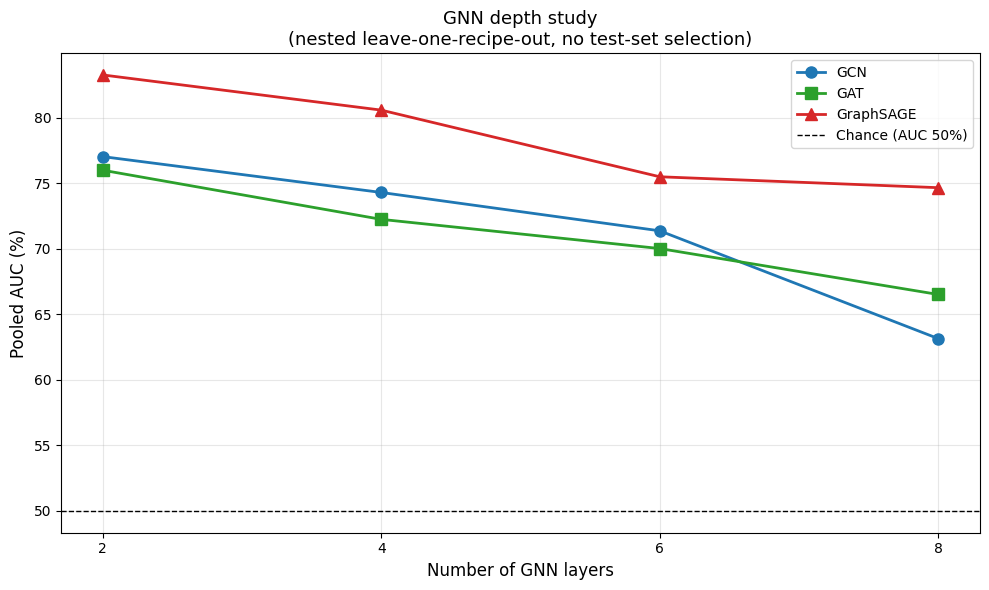


>>> READING THIS PLOT <<<
  GCN        : best at 2 layers; 2->8 layers degrades with depth (-13.89 points of AUC)
  GAT        : best at 2 layers; 2->8 layers degrades with depth (-9.48 points of AUC)
  GraphSAGE  : best at 2 layers; 2->8 layers degrades with depth (-8.60 points of AUC)

Oversmoothing is only demonstrated where the curve falls as depth grows.
A flat curve at these graph sizes is a real result too, and more likely to
mean the model is not using graph structure much in the first place -
compare against the SimplePooling baseline, which sees no edges at all.


In [21]:
# ==============================================================================
# VISUALIZATION: depth vs performance
# ==============================================================================
import matplotlib.pyplot as plt

if 'oversmoothing_results' in dir() and oversmoothing_results:
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = {'GCN': 'tab:blue', 'GAT': 'tab:green', 'GraphSAGE': 'tab:red'}
    markers = {'GCN': 'o', 'GAT': 's', 'GraphSAGE': '^'}

    for model_name, results in oversmoothing_results.items():
        depths = sorted(results.keys())
        vals = [results[d][DEPTH_METRIC] * 100 for d in depths]
        ax.plot(depths, vals, marker=markers[model_name], color=colors[model_name],
                label=model_name, linewidth=2, markersize=8)

    ax.axhline(50, color='k', linestyle='--', linewidth=1, label='Chance (AUC 50%)')
    ax.set_xlabel('Number of GNN layers', fontsize=12)
    ax.set_ylabel(f'Pooled {DEPTH_METRIC.upper()} (%)', fontsize=12)
    ax.set_title('GNN depth study\n(nested leave-one-recipe-out, no test-set selection)',
                 fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(DEPTH_CONFIGS)

    plt.tight_layout()
    plt.savefig('extension_data/gnn_depth_study.png', dpi=150, bbox_inches='tight')
    plt.show()

    # State what the numbers show, rather than asserting oversmoothing regardless.
    print("\n>>> READING THIS PLOT <<<")
    for model_name, results in oversmoothing_results.items():
        depths = sorted(results.keys())
        vals = [results[d][DEPTH_METRIC] for d in depths]
        best_d = depths[int(np.argmax(vals))]
        change = (vals[-1] - vals[0]) * 100      # signed: negative means it got worse
        trend = ("degrades with depth" if change < -2 else
                 "improves with depth" if change > 2 else
                 "is flat in depth")
        print(f"  {model_name:<11}: best at {best_d} layers; "
              f"{depths[0]}->{depths[-1]} layers {trend} "
              f"({change:+.2f} points of {DEPTH_METRIC.upper()})")
    print("\nOversmoothing is only demonstrated where the curve falls as depth grows.")
    print("A flat curve at these graph sizes is a real result too, and more likely to")
    print("mean the model is not using graph structure much in the first place -")
    print("compare against the SimplePooling baseline, which sees no edges at all.")
else:
    print("Run the depth study first")

---
## 8b. Hyperparameter sensitivity

Nine settings under the same nested protocol, reported as a stability check on the
headline number rather than as a search for the best one.

In [22]:
# ==============================================================================
# HYPERPARAMETER SENSITIVITY: learning rate x hidden width
# ==============================================================================
# This is a sensitivity analysis, not a model-selection procedure. The configuration
# reported above (lr 1e-3, hidden 128) was fixed before any test fold was scored, and
# it stays the reported one whatever this sweep shows. Picking the best cell of this
# table and reporting it would be selecting on the test folds, which is exactly the
# error the nested protocol exists to prevent.
#
# What the table is for: showing whether the result depends on a lucky setting. A flat
# surface means the number is a property of the data; a spiky one means it is not.

SWEEP_LRS = [3e-4, 1e-3, 3e-3]
SWEEP_HIDDEN = [64, 128, 256]

sweep = {}
for lr in SWEEP_LRS:
    for hidden in SWEEP_HIDDEN:
        _f, _p = leave_one_recipe_out_gnn(
            GCNClassifier, pyg_data, recipe_groups, input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS, lr=lr, batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT, n_val_recipes=N_VAL_RECIPES, seed=SEED,
            hidden_dim=hidden, num_layers=NUM_LAYERS, combine=COMBINE, verbose=False)
        binary = (_p['probs'] >= 0.5).astype(int)
        sweep[(lr, hidden)] = (balanced_accuracy_score(_p['labels'], binary),
                               roc_auc_score(_p['labels'], _p['probs']))
        print(f"  lr={lr:<7} hidden={hidden:<4} -> bal.acc {sweep[(lr, hidden)][0]*100:5.1f}%  "
              f"auc {sweep[(lr, hidden)][1]*100:5.1f}%")

for metric, idx in [("balanced accuracy", 0), ("AUC", 1)]:
    print(f"\npooled {metric} (%)")
    print("lr / hidden".ljust(14) + "".join(f"{h:>9}" for h in SWEEP_HIDDEN))
    for lr in SWEEP_LRS:
        print(f"{lr:<14}" + "".join(f"{sweep[(lr, h)][idx]*100:>8.1f} " for h in SWEEP_HIDDEN))

_vals = [v[1] for v in sweep.values()]
print(f"\nAUC across the 9 settings: min {min(_vals)*100:.1f}%  max {max(_vals)*100:.1f}%  "
      f"spread {(max(_vals)-min(_vals))*100:.1f} points")
print(f"Reported setting (lr={LEARNING_RATE}, hidden={HIDDEN_DIM}): "
      f"auc {sweep[(LEARNING_RATE, HIDDEN_DIM)][1]*100:.1f}%")

Folds: 100%|██████████| 24/24 [02:24<00:00,  6.01s/it]


  lr=0.0003  hidden=64   -> bal.acc  68.4%  auc  74.5%


Folds: 100%|██████████| 24/24 [02:25<00:00,  6.07s/it]


  lr=0.0003  hidden=128  -> bal.acc  68.6%  auc  74.2%


Folds: 100%|██████████| 24/24 [02:26<00:00,  6.09s/it]


...

  lr=0.003   hidden=64   -> bal.acc  70.8%  auc  79.3%


Folds: 100%|██████████| 24/24 [02:26<00:00,  6.11s/it]


  lr=0.003   hidden=128  -> bal.acc  65.8%  auc  75.8%


Folds: 100%|██████████| 24/24 [02:26<00:00,  6.12s/it]

  lr=0.003   hidden=256  -> bal.acc  74.7%  auc  77.1%

pooled balanced accuracy (%)
lr / hidden          64      128      256
0.0003            68.4     68.6     69.2 
0.001             68.2     69.8     67.9 
0.003             70.8     65.8     74.7 

pooled AUC (%)
lr / hidden          64      128      256
0.0003            74.5     74.2     77.3 
0.001             77.6     76.4     75.6 
0.003             79.3     75.8     77.1 

AUC across the 9 settings: min 74.2%  max 79.3%  spread 5.1 points
Reported setting (lr=0.001, hidden=128): auc 76.4%


---
## 8c. Directed vs undirected task graph

The task graph is a DAG and its edge direction encodes procedural order. The main results
keep it; this asks whether keeping it matters.

In [23]:
# ==============================================================================
# ABLATION: does the task graph's edge direction carry information?
# ==============================================================================
# CaptainCook4D task graphs are DAGs, and an edge a -> b means b depends on a. The main
# results keep that direction. Symmetrising the graph lets messages flow backwards in
# the procedure, which is what most GNN pipelines do by default and what this notebook
# used to do implicitly.
#
# Under directed edges a node only receives messages from its prerequisites, so nodes
# with no incoming edge receive none at all - which is a real modelling trade-off rather
# than an obviously worse choice. Hence the ablation.
#
# Read the result against the run-to-run spread: re-running this notebook unchanged
# moved GAT by 2.0 AUC, so only a gap clearly larger than that means anything.

undirected_data = {rid: create_pyg_data(g, rid, undirected=True)
                   for rid, g in GRAPHS_BY_SOURCE[PRIMARY_SOURCE].items()}

print(f"{'model':<14}{'edges':<14}{'edges/graph':>12}{'bal.acc':>10}{'auc':>9}")
print("-" * 59)

for _cls, _name in [(GCNClassifier, 'GCN'), (GATClassifier, 'GAT'),
                    (GraphSAGEClassifier, 'GraphSAGE')]:
    for _data, _tag in [(pyg_data, 'directed'), (undirected_data, 'undirected')]:
        _folds, _pooled = leave_one_recipe_out_gnn(
            _cls, _data, GROUPS_BY_SOURCE[PRIMARY_SOURCE], input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT, n_val_recipes=N_VAL_RECIPES, seed=SEED,
            hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, combine=COMBINE, verbose=False)
        _bin = (_pooled['probs'] >= 0.5).astype(int)
        _epg = np.mean([d.edge_index.shape[1] for d in _data.values()])
        print(f"{_name:<14}{_tag:<14}{_epg:>12.1f}"
              f"{balanced_accuracy_score(_pooled['labels'], _bin) * 100:>9.1f}%"
              f"{roc_auc_score(_pooled['labels'], _pooled['probs']) * 100:>8.1f}%")

model         edges          edges/graph   bal.acc      auc
-----------------------------------------------------------


Folds: 100%|██████████| 24/24 [02:25<00:00,  6.06s/it]


GCN           directed              15.3     69.0%    77.2%


Folds: 100%|██████████| 24/24 [02:24<00:00,  6.01s/it]


GCN           undirected            30.6     70.9%    78.8%


...

GAT           undirected            30.6     76.1%    83.5%


Folds: 100%|██████████| 24/24 [02:13<00:00,  5.56s/it]


GraphSAGE     directed              15.3     76.9%    81.8%


Folds: 100%|██████████| 24/24 [02:11<00:00,  5.50s/it]

GraphSAGE     undirected            30.6     76.5%    81.5%


---
## 9. What is the model actually using?

The results above are strong enough to be worth interrogating. Hungarian matching assigns
`min(num_visual_steps, num_nodes)` pairs, so `node_matched.sum() / num_nodes` is exactly the
fraction of a recipe's canonical steps that appear in the recording. That quantity requires no
video, no encoder and no training.

CaptainCook4D's error taxonomy contains a **Missing Step** tag (285 occurrences across the
dataset), so a recording that omits a step is labelled incorrect *by definition*. The three
cells below ask how much of the reported score that single fact accounts for.

These three cells analyse the **primary source** (`PRIMARY_SOURCE`, the annotated
boundaries), because that is where the shortcut lives. The comparison table above
already reports every model on both boundary sources.


In [24]:
# ==============================================================================
# A one-line rule with no learning in it
# ==============================================================================
# "Predict incorrect whenever at least one canonical step is absent."
# Scored on the same recordings, with the same metrics, as every model above.

rule_frac = np.array([g['node_matched'].sum() / g['num_nodes']
                      for g in realized_graphs.values()], dtype=float)
rule_labels = np.array([float(g['recipe_label']) for g in realized_graphs.values()])
rule_pred = (rule_frac < 1.0).astype(int)

header = f"{'':<28}{'prec':>9}{'rec':>9}{'f1':>9}{'bal.acc':>9}{'auc':>9}"
print(header)
print("-" * len(header))
print(f"{'rule: a step is absent':<28}"
      f"{precision_score(rule_labels, rule_pred, zero_division=0) * 100:>8.1f}%"
      f"{recall_score(rule_labels, rule_pred, zero_division=0) * 100:>8.1f}%"
      f"{f1_score(rule_labels, rule_pred, zero_division=0) * 100:>8.1f}%"
      f"{balanced_accuracy_score(rule_labels, rule_pred) * 100:>8.1f}%"
      f"{roc_auc_score(rule_labels, -rule_frac) * 100:>8.1f}%")
for (source, name), res in all_model_results.items():
    if source != PRIMARY_SOURCE:
        continue
    print(f"{name:<28}{res['precision']['pooled'] * 100:>8.1f}%"
          f"{res['recall']['pooled'] * 100:>8.1f}%{res['f1']['pooled'] * 100:>8.1f}%"
          f"{res['balanced_accuracy']['pooled'] * 100:>8.1f}%{res['auc']['pooled'] * 100:>8.1f}%")

print(f"\nStep counts: {(rule_frac < 1.0).sum()} of {len(rule_frac)} recordings are missing at "
      f"least one canonical step.")
print("The rule is deterministic and uses no features, so it has no folds and no variance.")

                                 prec      rec       f1  bal.acc      auc
-------------------------------------------------------------------------
rule: a step is absent          99.2%    58.9%    73.9%    79.1%    79.2%
SimplePooling                   89.4%    65.8%    75.8%    77.7%    81.4%
GCN                             77.6%    64.8%    70.6%    69.9%    77.5%
GAT                             74.6%    65.8%    69.9%    67.9%    74.4%
GraphSAGE                       85.1%    65.3%    73.9%    75.0%    80.7%

Step counts: 130 of 383 recordings are missing at least one canonical step.
The rule is deterministic and uses no features, so it has no folds and no variance.


In [25]:
# ==============================================================================
# Which part of the node input carries the signal?
# ==============================================================================
# Same model, same folds, same seed; only the node feature block changes.
#
#   full       [visual | text | matched]   what the results above report
#   mask only  [  0    |  0   | matched]   the step-count shortcut, nothing else
#   no count   [visual*| text |    1   ]   the embeddings, with the count suppressed
#
# If 'mask only' reaches 'full', the 256-dim EgoVLP embeddings are not contributing.
#
# 'no count' needs care. Substep 3 leaves an unmatched node's visual block as all
# zeros, so clearing the matched flag alone removes nothing - the count is still
# legible from which rows have a zero visual block. This variant therefore also fills
# unmatched nodes' visual block with their own text embedding, so every node looks
# realized. A residual channel survives (visual == text marks an unmatched node), so
# treat this row as an upper bound on how little the count matters, and read the
# omission-free subset below as the decisive test.

def make_variant(data_dict, mode):
    """Copy the PyG graphs with one block of the node features neutralised."""
    out = {}
    for rid, d in data_dict.items():
        g = d.clone()
        if mode == 'mask_only':
            g.x[:, :2 * FEATURE_DIM] = 0.0
        elif mode == 'no_count':
            unmatched = g.x[:, 2 * FEATURE_DIM] < 0.5
            g.x[unmatched, :FEATURE_DIM] = g.x[unmatched, FEATURE_DIM:2 * FEATURE_DIM]
            g.x[:, 2 * FEATURE_DIM:] = 1.0
        elif mode != 'full':
            raise ValueError(mode)
        out[rid] = g
    return out


ABLATION_MODEL = GCNClassifier
ablation_rows = []

for mode in ['full', 'mask_only', 'no_count']:
    variant = make_variant(pyg_data, mode)
    folds, pooled = leave_one_recipe_out_gnn(
        ABLATION_MODEL, variant, recipe_groups, input_dim=FEATURE_DIM,
        num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE,
        pos_weight=POS_WEIGHT, n_val_recipes=N_VAL_RECIPES, seed=SEED,
        hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, combine=COMBINE, verbose=False)
    binary = (pooled['probs'] >= 0.5).astype(int)
    ablation_rows.append((mode,
                          balanced_accuracy_score(pooled['labels'], binary),
                          roc_auc_score(pooled['labels'], pooled['probs'])))
    print(f"  {mode:<12} done")

print(f"\n{'input':<14}{'bal.acc':>10}{'auc':>10}")
print("-" * 34)
for mode, bacc, auc in ablation_rows:
    print(f"{mode:<14}{bacc * 100:>9.1f}%{auc * 100:>9.1f}%")

Folds: 100%|██████████| 24/24 [02:26<00:00,  6.10s/it]


  full         done


Folds: 100%|██████████| 24/24 [02:27<00:00,  6.14s/it]


  mask_only    done


Folds: 100%|██████████| 24/24 [02:27<00:00,  6.13s/it]

  no_count     done

input            bal.acc       auc
----------------------------------
full               69.0%     75.9%
mask_only          77.3%     76.6%
no_count           69.2%     77.0%


In [26]:
# ==============================================================================
# Does anything survive once the count shortcut is removed?
# ==============================================================================
# Restrict to recordings containing no Missing Step error. Every remaining positive is
# an Order, Technique, Preparation, Measurement, Timing or Temperature error - none of
# which change how many steps were performed, so the shortcut cannot fire.

import json

with open('annotations/annotation_json/error_annotations.json', 'r') as f:
    _error_annotations = json.load(f)

omission = set()
for rec in _error_annotations:
    for step in rec.get('step_annotations', []):
        for err in (step.get('errors') or []):
            if err.get('tag') == 'Missing Step':
                omission.add(rec['recording_id'])

subset_ids = [r for r in pyg_data if r not in omission]
subset_data = {r: pyg_data[r] for r in subset_ids}
subset_groups = {rec: [r for r in ids if r in subset_data]
                 for rec, ids in recipe_groups.items()}
subset_groups = {k: v for k, v in subset_groups.items() if len(v) >= 2}

sub_labels = np.array([float(realized_graphs[r]['recipe_label']) for r in subset_ids])
sub_frac = np.array([realized_graphs[r]['node_matched'].sum() / realized_graphs[r]['num_nodes']
                     for r in subset_ids], dtype=float)

print(f"Recordings without an omission error: {len(subset_ids)} "
      f"({sub_labels.mean():.1%} labelled incorrect)")
print(f"Rule AUC on this subset: {roc_auc_score(sub_labels, -sub_frac) * 100:.1f}%  "
      f"(it should be near 50% - the shortcut is gone by construction)")

folds, pooled = leave_one_recipe_out_gnn(
    GCNClassifier, subset_data, subset_groups, input_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT, n_val_recipes=N_VAL_RECIPES, seed=SEED,
    hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, combine=COMBINE, verbose=False)

summarize_results(folds, pooled, "GCN - omission-free subset", num_epochs=NUM_EPOCHS)
print("\nThis is the number that says whether the visual features, the text encoder and")
print("the matching contribute anything beyond counting steps.")

Recordings without an omission error: 244 (32.8% labelled incorrect)
Rule AUC on this subset: 52.2%  (it should be near 50% - the shortcut is gone by construction)


Folds: 100%|██████████| 24/24 [01:37<00:00,  4.05s/it]


GCN - omission-free subset  -  pooled over 24 folds, 244 recordings
metric                     model    majority
accuracy                  48.36%      67.21%
precision                 23.86%           -
recall                    26.25%           -
f1                        25.00%       0.00%
balanced_accuracy         42.70%      50.00%
auc                       46.79%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            48.23% +/- 15.96%
  precision           14.77% +/- 18.08%
  recall              24.58% +/- 30.19%
  f1                  17.60% +/- 20.82%
  balanced_accuracy   44.54% +/- 12.37%
  auc                 47.48% +/- 18.33%

Selected epoch: mean 2.2 of 50, median 2, max 5
  -> validation loss bottoms out within the first few epochs; and it does not beat the baseline: the model is memorising the training folds rather than learning from them.
Positive rate: 36.07% (true: 32.79%)

This is the number that says whether the visual features, the text e